In [ ]:
import random
import json
import re
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import response_processing as rp
from src.viz_utils import qa_viz
from src.STAR_utils.visualization_tools import qa_visualization as qaviz

random.seed(6)
np.random.seed(6)

STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"

#VQA_RESP_FILEPATH = WORK_DIR / "outputs/vqa_gemma3:4b-it-qat_20250619_20:59:00.jsonl" #VQA1
#VQA_RESP_FILEPATH = WORK_DIR / "outputs/vqa_without_noneoftheothers_alt_gemma3:4b-it-qat_20250622_23:17:00.jsonl" #VQA4
#VQA_RESP_FILEPATH = WORK_DIR / "outputs/vqa_fixorder_video_fps_gemma3:4b-it-qat_20250710_23:13:00.jsonl" #VQA6
VQA_RESP_FILEPATH = WORK_DIR / "outputs/vqa_u3_fixorder_video_fps_gemma3:4b-it-qat_20250711_16:16:00.jsonl" #VQA7
#VQA_RESP_FILEPATH = WORK_DIR / "outputs/vqa_u3_fixorder_video_fps_maxframes5_gemma3:4b-it-qat_20250712_10:20:00.jsonl" #VQA?? ~ VQA4 but new sampling method

#QA_GEN_GRAPHS = WORK_DIR / "outputs/responses_on_small_val_gemma3:4b-it-qat_20250609_21:50:00.jsonl" #GQA1
#QA_GEN_GRAPHS = WORK_DIR / "outputs/gu_on_sgg_union_oneframeprompt_gemma3:4b-it-qat_20250709_08:00:00.jsonl" #GQA6
QA_GEN_GRAPHS = WORK_DIR / "outputs/gqa_u3_all_sgg_20250711_16:11:00.jsonl" #GQA7
#QA_GEN_GRAPHS = WORK_DIR / "outputs/gqa_u4_all_sgg_20250711_16:11:00.jsonl" #GQA8
#QA_GEN_GRAPHS = WORK_DIR / "outputs/gqa_u3_oneframeprompt_sgg_20250708_10:37:00.jsonl" #GQA9
#QA_GEN_GRAPHS = WORK_DIR / "outputs/gqa_u4_oneframeprompt_maxframes5_sgg_20250605_11:09:00.jsonl" #GQA10
#QA_GEN_GRAPHS = WORK_DIR / "outputs/gqa_u3_all_sgg_20250712_09:55:00.jsonl" #GQA11
#QA_GEN_GRAPHS = WORK_DIR / "outputs/gqa_u4_all_sgg_20250712_09:55:00.jsonl" #GQA12


RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


# Experiment
### Comparison between VQA and QA on generated frames - same sample rate


**Parameters:**
- model: Gemma3:4b-it-qat
- user_prompt: vqa/user_prompt_v2.txt
- temperature: 0.1
- sampling method: (default) top-p (p=0.9)

## Load GT

In [2]:
ground_truth = []

with open('../data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json') as f:
    data = json.load(f)
    ground_truth = [{
        'id': sample['question_id'],
        'question': sample['question'],
        'choices': sample['choices'],
        'text': sample['answer'],
    } for sample in data]


# we keep num as str so we can directrly access choices dictionaries
gt_df = pd.DataFrame(ground_truth).astype({'id': 'string', 'text': 'string'})
gt_df.set_index('id', inplace=True)
gt_df


,question,choices,text
id,,,
Feasibility_T5_102,Which object is the person able to throw after...,"[{'choice_id': 0, 'choice': 'The bag.', 'choic...",The clothes.
Feasibility_T2_860,What else is the person able to do with the wi...,"[{'choice_id': 0, 'choice': 'Lie on the window...",Close the window.
Feasibility_T2_556,What else is the person able to do with the cl...,"[{'choice_id': 0, 'choice': 'Tidy up the close...",Open the closet/cabinet.
Prediction_T1_2539,What will the person do next?,"[{'choice_id': 0, 'choice': 'Sit on the floor....",Sit on the floor.
Prediction_T4_1253,Which object would the person throw next after...,"[{'choice_id': 0, 'choice': 'The pillow.', 'ch...",The shoe.
...,...,...,...
Interaction_T1_8913,Which object was taken by the person?,"[{'choice_id': 0, 'choice': 'The paper/noteboo...",The paper/notebook.
Interaction_T1_8967,Which object was taken by the person?,"[{'choice_id': 0, 'choice': 'The towel.', 'cho...",The dish.
Interaction_T2_1847,What did the person do with the paper/notebook?,"[{'choice_id': 0, 'choice': 'Put down.', 'choi...",Took.


## Loading predicted answers evaluation

In [3]:
gt_df = None
with open(STAR_VAL_SMALL, 'r') as f:
    gt_df = pd.read_json(f)

gt_df = gt_df.rename(columns={'answer': 'text'})
gt_df = gt_df.set_index('question_id')
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   object 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
dtypes: float64(2), object(6)
memory usage: 73.7+ KB


In [4]:
pred_vqa_df = rp.gemma3_ans_extract(VQA_RESP_FILEPATH)
pred_gg_df = rp.gemma3_ans_extract(QA_GEN_GRAPHS)

pred_vqa_df = pred_vqa_df[pred_vqa_df['contains_answer']]
pred_gg_df = pred_gg_df[pred_gg_df['contains_answer']]


Total answers: 1039
Answers following JSON template: 1039
Percentage following JSON template: 100.00%
Answer following the template: 1021
98.27% of the total

Only 18 samples do not contain the answer in the response with the specified format


/home/lusha/star_code/src/response_processing.py:182: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df["answer"] \


Total answers: 1048
Answers following JSON template: 1048
Percentage following JSON template: 100.00%
Answer following the template: 1048
100.00% of the total

Only 0 samples do not contain the answer in the response with the specified format


/home/lusha/star_code/src/response_processing.py:182: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df["answer"] \


In [5]:
pred_vqa_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df1 = gt_df.join(
    pred_vqa_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df1, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          293        48.81%  
Sequence             285        52.63%  
Prediction           228        43.86%  
Feasibility          215        40.00%  

Average             1021        46.91%  


In [6]:
rp.print_ans_perc(eval_df1, gt_df)


Question type       Total      Answered 

Interaction          298        98.32%  
Sequence             291        97.94%  
Prediction           239        95.40%  
Feasibility          220        97.73%  
Overall             1048        97.42%  


In [7]:
pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df2 = gt_df.join(
    pred_gg_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df2, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          298        39.93%  
Sequence             291        48.80%  
Prediction           239        56.49%  
Feasibility          220        55.00%  

Average             1048        49.33%  


In [8]:
rp.print_ans_perc(eval_df2, gt_df)


Question type       Total      Answered 

Interaction          298       100.00%  
Sequence             291       100.00%  
Prediction           239       100.00%  
Feasibility          220       100.00%  
Overall             1048       100.00%  


In [9]:
print(pred_gg_df.iloc[0]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
[['person - holding - clothes', 'person - in_front_of - clothes'], ['person - holding - clothes', 'person - in_front_of - clothes'], ['person - holding - clothes', 'person - in_front_of - clothes'], ['person - holding - clothes', 'person - in_front_of - clothes'], ['person - holding - clothes', 'person - in_front_of - clothes'], ['person - holding - clothes', 'person - wearing - clothes', 'person - in_front_of - clothes'], ['person - touching - clothes', 'person - wearing - clothes'], ['person - holding - clothes', 'person - wearing - clothes', 'person - in_front_of - clothes'], ['person - wearing - clothes'], ['person - touching - clothes', 'person - wearing - clothes'], ['person - touching - clothes', 'person - wearing - clothes'], ['person - touching - clothes', 'person - wearing - clothes', 'person - in_front_of - blanket', 'person - on_t

In [10]:
pred_vqa_df.rename(columns={'pred_text': 'pred_text1'}, inplace=True)
pred_gg_df.rename(columns={'pred_text': 'pred_text2'}, inplace=True)
eval_df_all = gt_df.join(
    pred_vqa_df[['pred_text1']],
    how='inner'
).join(
    pred_gg_df[['pred_text2']],
    how='inner'
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()
eval_df_all


,question,video_id,start,end,text,question_program,choices,situations,pred_text1,pred_text2
Feasibility_T5_102,Which object is the person able to throw after...,ATV2F,0.0,4.000,the clothes.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The bag.', 'choic...","{'000031': {'rel_pairs': [['o000', 'o019'], ['...",the bag.,the blanket.
Feasibility_T2_860,What else is the person able to do with the wi...,9J166,9.9,17.500,close the window.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'Lie on the window...","{'000321': {'rel_pairs': [['o000', 'o017'], ['...",hold the window.,none of the others.
Feasibility_T2_556,What else is the person able to do with the cl...,ANA5N,4.3,10.300,open the closet/cabinet.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'Tidy up the close...","{'000390': {'rel_pairs': [['o000', 'o011'], ['...",open the closet/cabinet.,open the closet/cabinet.
Prediction_T1_2539,What will the person do next?,Z6HEA,0.0,10.875,sit on the floor.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'Sit on the floor....","{'000021': {'rel_pairs': [['o000', 'o027'], ['...",tidy up the table.,sit on the floor.
Prediction_T4_1253,Which object would the person throw next after...,FRLW2,3.4,27.275,the shoe.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The pillow.', 'ch...","{'000811': {'rel_pairs': [['o000', 'o022'], ['...",the pillow.,the shoe.
...,...,...,...,...,...,...,...,...,...,...
Interaction_T1_8913,Which object was taken by the person?,F9YMU,11.9,16.500,the paper/notebook.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The paper/noteboo...","{'000213': {'rel_pairs': [['o000', 'o006'], ['...",the paper/notebook.,the paper/notebook.
Interaction_T1_8967,Which object was taken by the person?,1333C,8.0,13.100,the dish.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The towel.', 'cho...","{'000241': {'rel_pairs': [['o000', 'o027'], ['...",the towel.,the dish.
Interaction_T2_1847,What did the person do with the paper/notebook?,1TIAK,8.3,12.500,took.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'Put down.', 'choi...","{'000210': {'rel_pairs': [['o000', 'o011']], '...",took.,took.
Interaction_T2_3423,What did the person do with the bed?,KU656,0.0,6.800,lied on.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'Sat on.', 'choice...","{'000019': {'rel_pairs': [['o000', 'o018'], ['...",lied on.,lied on.


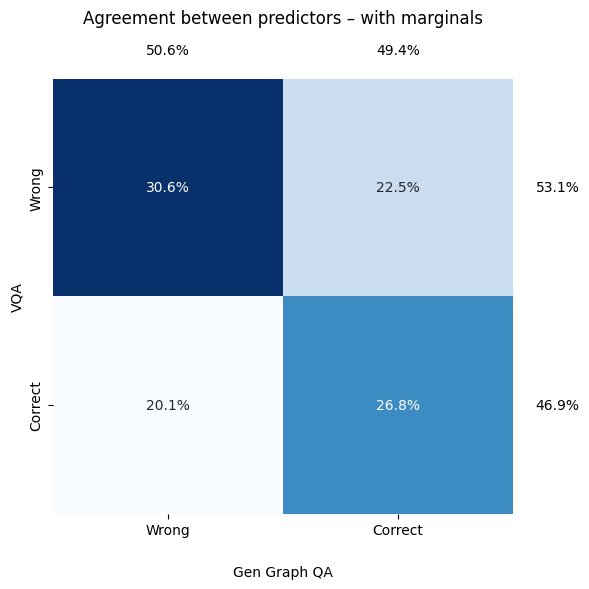

(1021, 10)


In [11]:
# your data
display_eval = eval_df_all
pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_gg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# annotate row marginals at the right of each row
for i, p in enumerate(row_pct):
    ax.text(len(labels) + 0.1,  i + 0.5, f'{p:.1%}', 
            va='center', ha='left', fontsize=10)

# annotate column marginals just above each column
for j, p in enumerate(col_pct):
    ax.text(j + 0.5, -0.1, f'{p:.1%}', 
            ha='center', va='bottom', fontsize=10)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Gen Graph QA', labelpad=20)
ax.set_ylabel('VQA')
ax.set_title('Agreement between predictors – with marginals', pad=40)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()
print(eval_df_all.shape)
